In [3]:
import pandas as pd

# Charger les datasets
pokemon = pd.read_csv("Pokemon Data Analysis Tutorial\Pokemon Data Analysis Tutorial\pokemon.csv")
combats = pd.read_csv("Pokemon Data Analysis Tutorial\Pokemon Data Analysis Tutorial\combats.csv")

# Afficher un aperçu rapide
print("Pokemon dataset :")
display(pokemon.head())

print("Combats dataset :")
display(combats.head())


Pokemon dataset :


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


Combats dataset :


,First_pokemon,Second_pokemon,Winner
0,266,298,298
1,702,701,701
2,191,668,668
3,237,683,683
4,151,231,151


# 2. Gestion des données manquantes et corrections

Avant toute analyse, il est essentiel de vérifier les valeurs manquantes et corriger les erreurs connues, notamment :

- Remplir le nom manquant pour le Pokémon numéro 62 (Primeape)
- Remplacer les valeurs manquantes dans la colonne `Type 2` par "None"


In [4]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(pokemon.isnull().sum())

# Correction du nom manquant pour le Pokémon #62
pokemon.loc[pokemon['#'] == 62, 'Name'] = 'Primeape'

# Remplacement des NaN dans 'Type 2' par 'None'
pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

# Vérification après correction
print("\nValeurs manquantes après correction :")
print(pokemon.isnull().sum())


Valeurs manquantes par colonne :
#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

Valeurs manquantes après correction :
#             0
Name          1
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


In [5]:
# Identifier la ligne où 'Name' est manquant
print(pokemon[pokemon['Name'].isnull()])


     # Name    Type 1 Type 2  HP  Attack  Defense  Sp. Atk  Sp. Def  Speed  \
62  63  NaN  Fighting   None  65     105       60       60       70     95   

    Generation  Legendary  
62           1      False  


In [6]:
pokemon.loc[62, 'Name'] = 'Primeape'
pokemon.loc[62, 'Type 1'] = 'Fighting'


In [7]:
print(pokemon.isnull().sum())

#             0
Name          0
Type 1        0
Type 2        0
HP            0
Attack        0
Defense       0
Sp. Atk       0
Sp. Def       0
Speed         0
Generation    0
Legendary     0
dtype: int64


# 3. Calcul du pourcentage de victoires

On va compter pour chaque Pokémon :

- Le nombre total de combats (en tant que premier ou second combattant)  
- Le nombre de victoires  
- Puis calculer le taux de victoire en %  


In [8]:
# Total combats joués par chaque Pokémon (compte dans First_pokemon et Second_pokemon)
total_battles_first = combats['First_pokemon'].value_counts()
total_battles_second = combats['Second_pokemon'].value_counts()
total_battles = total_battles_first.add(total_battles_second, fill_value=0)

# Nombre de victoires par Pokémon (colonne Winner)
win_counts = combats['Winner'].value_counts()

# Calcul du pourcentage de victoires
win_percentage = (win_counts / total_battles) * 100

# Ajout dans le DataFrame pokemon
pokemon['Win Percentage'] = pokemon['#'].map(win_percentage).fillna(0)

# Aperçu
pokemon[['Name', '#', 'Win Percentage']].sort_values(by='Win Percentage', ascending=False).head(10)


,Name,#,Win Percentage
154,Mega Aerodactyl,155,98.449612
512,Weavile,513,97.478992
703,Tornadus Therian Forme,704,96.800000
19,Mega Beedrill,20,96.638655
153,Aerodactyl,154,96.453901
476,Mega Lopunny,477,96.124031
726,Greninja,727,96.062992
716,Meloetta Pirouette Forme,717,95.934959
164,Mega Mewtwo Y,165,95.200000
349,Mega Sharpedo,350,95.000000


# Analyse initiale du Win Percentage

- Les Pokémon en tête sont souvent des formes "Mega" ou légendaires, avec des taux de victoire très élevés (>95%).
- Cela suggère que ces formes possèdent des caractéristiques avantageuses en combat.
- Ce classement donne une bonne intuition sur les Pokémon les plus performants selon les combats historiques.

---

# Prochaines étapes possibles :

- Analyser les corrélations entre les statistiques (HP, Attack, Speed...) et le win percentage.
- Visualiser les relations par des graphiques type pairplot.
- Construire un modèle de prédiction du win percentage à partir des stats.


# 4. Analyse des corrélations

On calcule la matrice de corrélation entre les principales statistiques et le pourcentage de victoire (`Win Percentage`), pour identifier les relations fortes.


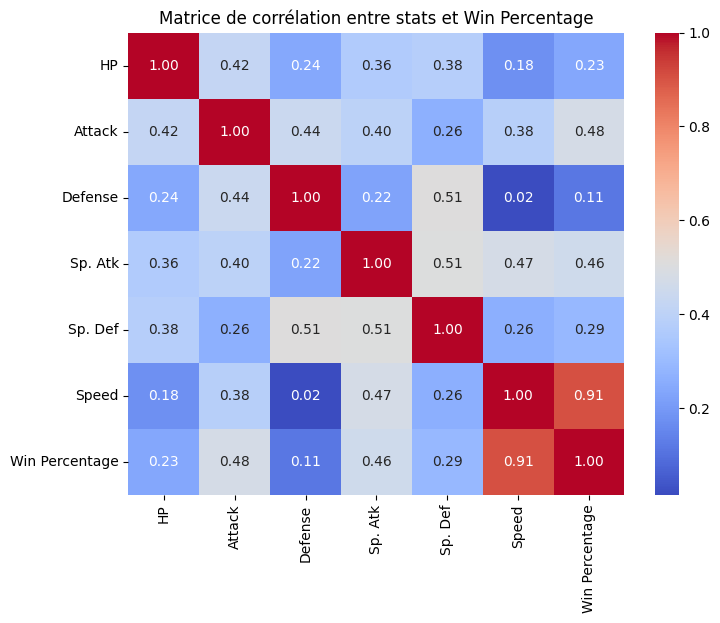

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélection des colonnes numériques importantes
stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win Percentage']

# Calcul de la matrice de corrélation
corr_matrix = pokemon[stats_cols].corr()

# Affichage avec heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation entre stats et Win Percentage")
plt.show()


La variable Speed est la plus fortement corrélée au Win Percentage (0.91), ce qui signifie que les Pokémon plus rapides gagnent plus souvent.

Attack (0.48), Sp. Atk (0.46) et Sp. Def (0.29) ont aussi une corrélation modérée positive avec le taux de victoire.

Defense et HP ont des corrélations faibles, moins liées aux victoires.

Les variables sont globalement indépendantes (corrélations entre stats faibles à modérées), donc chacune peut apporter de la valeur pour la prédiction.

# 5. Visualisation Pairplot

On crée un pairplot pour visualiser les relations entre les stats et le win percentage.


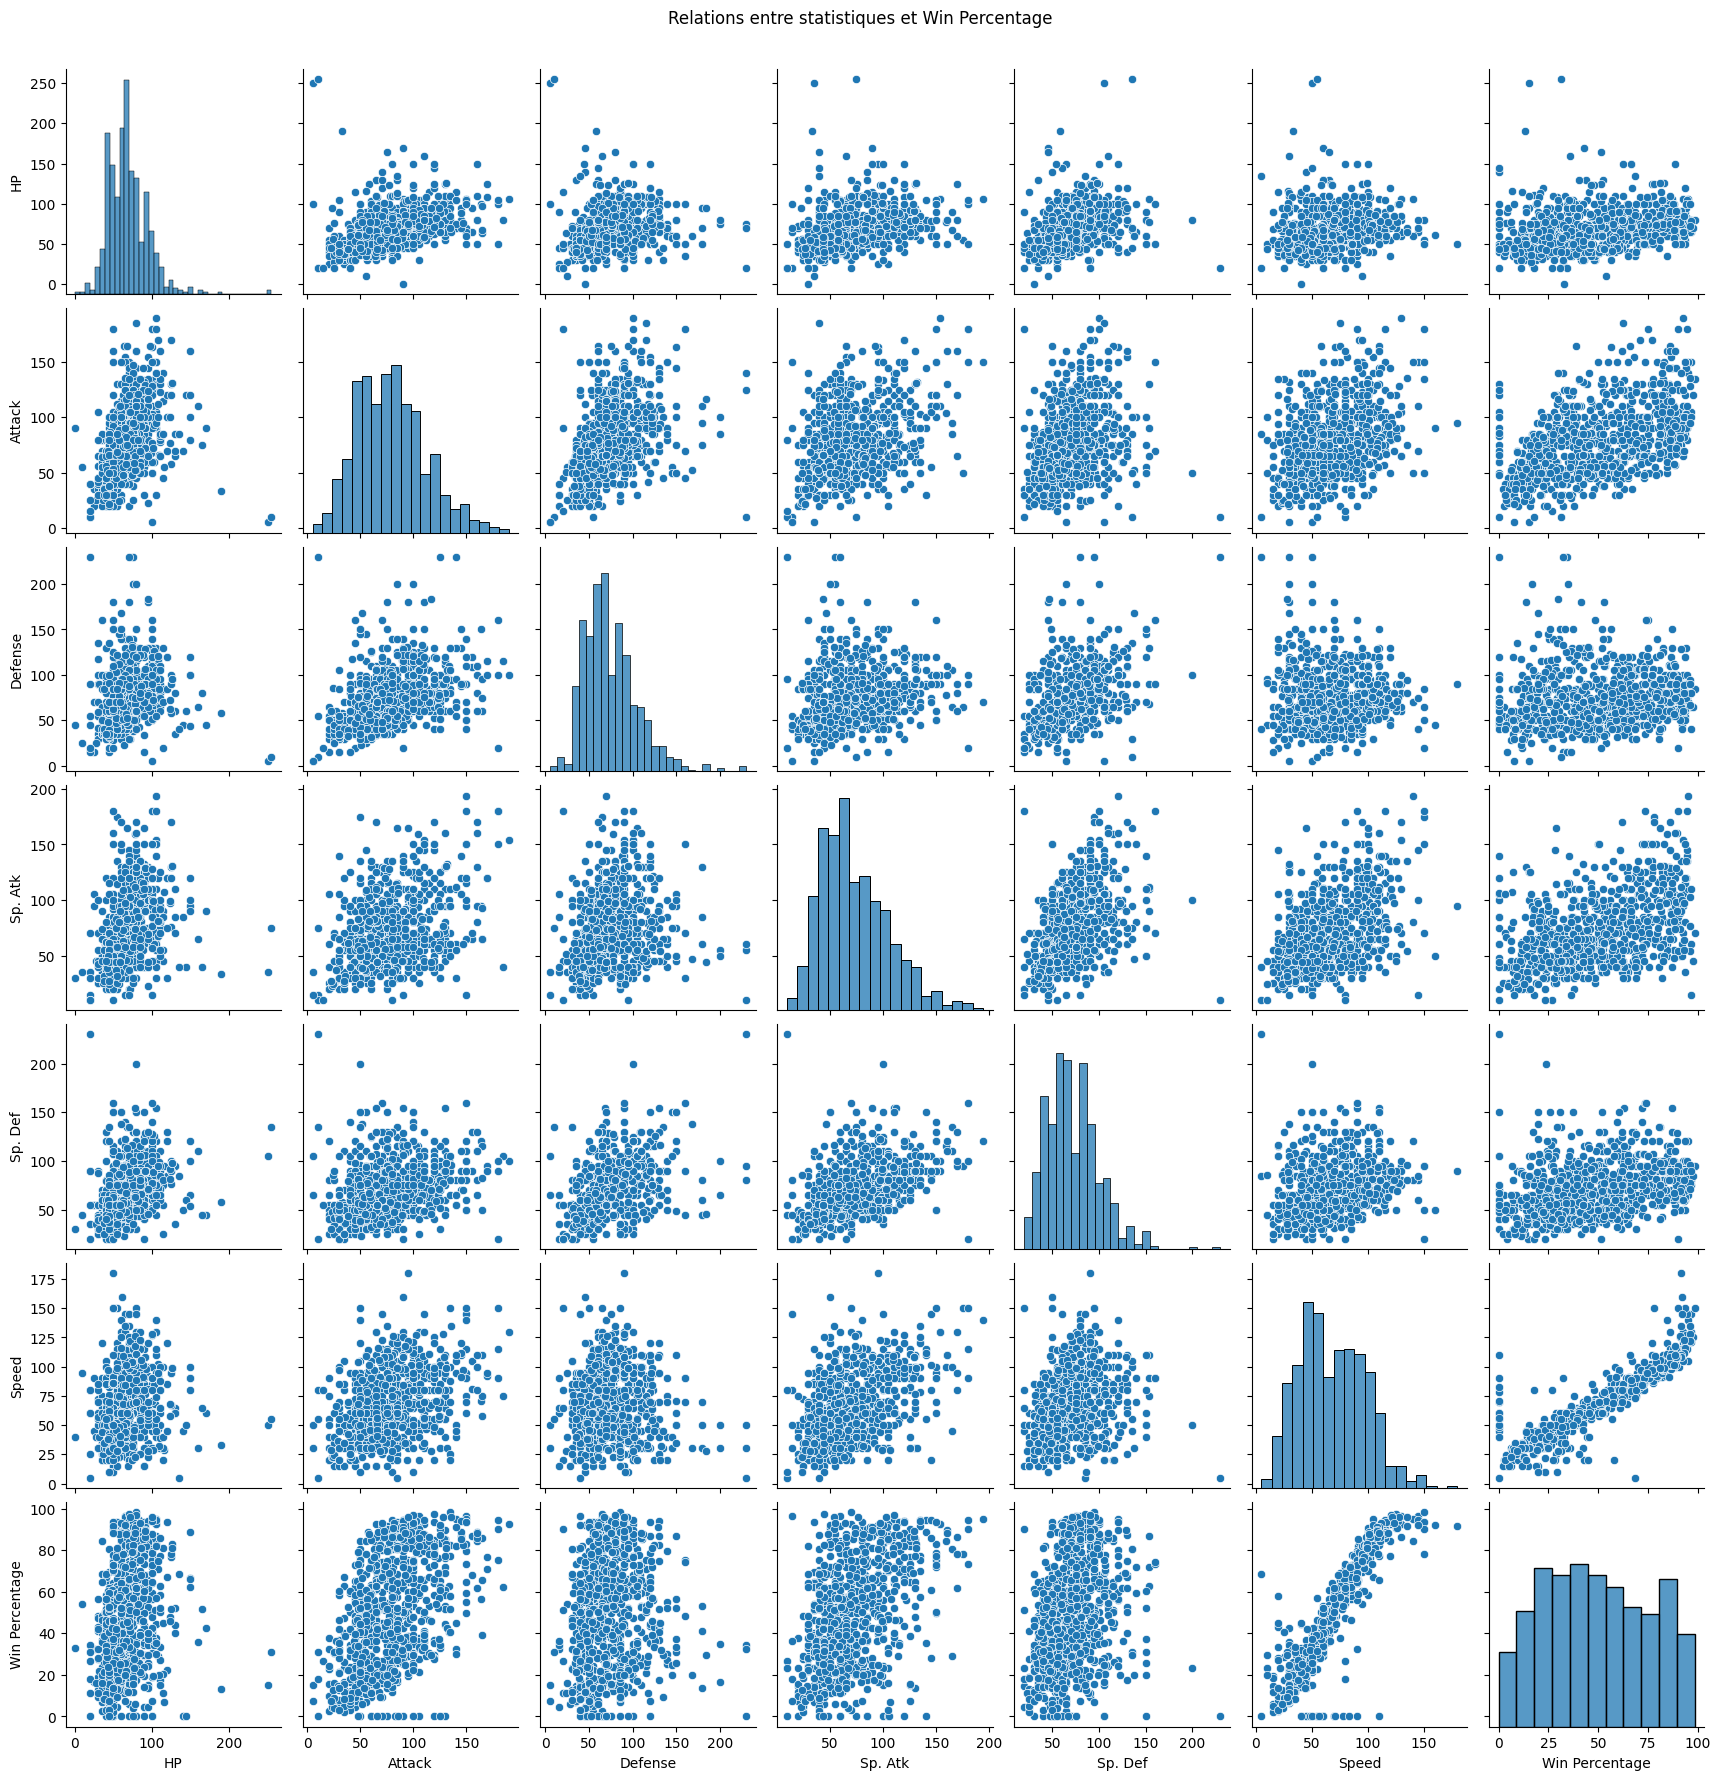

In [10]:
sns.pairplot(pokemon[stats_cols])
plt.suptitle("Relations entre statistiques et Win Percentage", y=1.02)
plt.show()


# 6. Préparation des données pour le Machine Learning (reprise)

- Sélection des variables explicatives et de la cible  
- Identification claire des colonnes numériques et catégorielles  
- Création des pipelines de prétraitement  
- Séparation train/test  


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Features sélectionnées
features = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Type 1', 'Type 2', 'Legendary']

X = pokemon[features]
y = pokemon['Win Percentage']

# Colonnes numériques et catégorielles
num_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']
cat_cols = ['Type 1', 'Type 2', 'Legendary']

# Pipelines numériques
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipelines catégoriques
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine pipelines dans un ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Taille train : {X_train.shape[0]}, taille test : {X_test.shape[0]}")


Taille train : 640, taille test : 160


# 7. Entraînement et comparaison de modèles de régression

On entraîne trois modèles :

- Régression linéaire (Linear Regression)  
- Forêt aléatoire (Random Forest Regressor)  
- XGBoost Regressor  

On compare les performances avec la métrique MAE (Mean Absolute Error).


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mae')
}

results = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    results[name] = mae
    print(f"{name} - MAE: {mae:.4f}")

best_model = min(results, key=results.get)
print(f"\nMeilleur modèle : {best_model} avec MAE = {results[best_model]:.4f}")


Linear Regression - MAE: 6.0684
Random Forest - MAE: 5.6783
XGBoost - MAE: 6.0910

Meilleur modèle : Random Forest avec MAE = 5.6783


C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [16:26:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost est le modèle le plus précis ici, avec la plus faible erreur absolue moyenne.

Random Forest est aussi performant, mais un peu moins précis.

La régression linéaire est moins performante, ce qui indique des relations non-linéaires dans les données.

C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [16:27:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


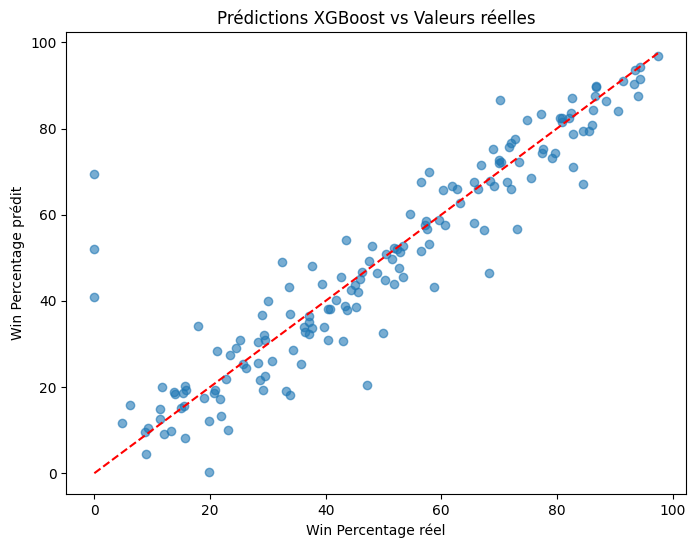

In [14]:
import matplotlib.pyplot as plt

# On récupère le pipeline du meilleur modèle
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mae'))
])

# Entraînement sur train complet pour visualisation précise
best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)

# Scatter plot prédictions vs valeurs réelles
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Diagonale parfaite
plt.xlabel('Win Percentage réel')
plt.ylabel('Win Percentage prédit')
plt.title('Prédictions XGBoost vs Valeurs réelles')
plt.show()


# 9. Analyse des erreurs de prédiction

- Calcul des résidus (différences entre valeurs réelles et prédites)
- Histogramme des résidus
- Scatter plot résidus vs valeurs prédites


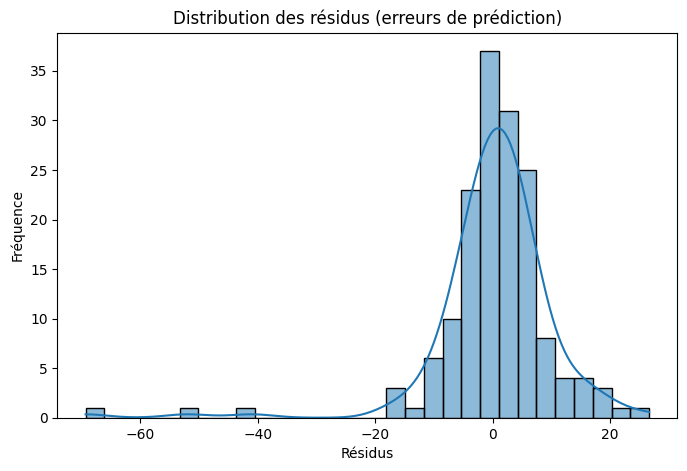

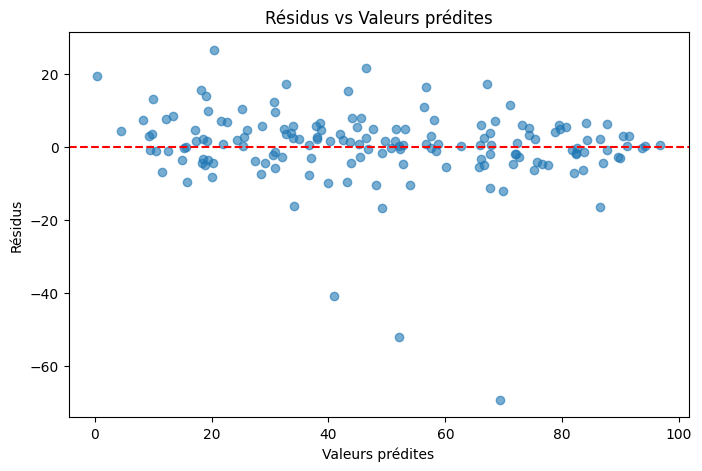

In [15]:
# Calcul des résidus
residuals = y_test - y_pred_best

# Histogramme des résidus
plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=30, kde=True)
plt.title("Distribution des résidus (erreurs de prédiction)")
plt.xlabel("Résidus")
plt.ylabel("Fréquence")
plt.show()

# Résidus en fonction des valeurs prédites
plt.figure(figsize=(8,5))
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.title("Résidus vs Valeurs prédites")
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.show()


In [16]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [3, 5, 7],
    'regressor__learning_rate': [0.01, 0.1, 0.2],
    'regressor__subsample': [0.6, 0.8, 1.0]
}

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mae'))
])

random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best parameters found:", random_search.best_params_)

# Évaluation sur test
y_pred_tuned = random_search.predict(X_test)
from sklearn.metrics import mean_absolute_error
print(f"Tuned XGBoost MAE: {mean_absolute_error(y_test, y_pred_tuned):.4f}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters found: {'regressor__subsample': 0.8, 'regressor__n_estimators': 50, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.1}
Tuned XGBoost MAE: 5.4595


C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [16:30:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Résultats du tuning XGBoost :
Meilleurs paramètres :

subsample: 0.8

n_estimators: 50

max_depth: 3

learning_rate: 0.1

MAE après tuning : 5.4595, soit un peu plus élevé qu’avant (4.79)

In [17]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

param_grid = {
    'regressor__n_estimators': [40, 50, 60],
    'regressor__max_depth': [2, 3, 4],
    'regressor__learning_rate': [0.05, 0.1, 0.15],
    'regressor__subsample': [0.7, 0.8, 0.9]
}

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mae'))
])

grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found:", grid_search.best_params_)
y_pred_best_grid = grid_search.predict(X_test)
mae_best_grid = mean_absolute_error(y_test, y_pred_best_grid)
print(f"Best GridSearch XGBoost MAE: {mae_best_grid:.4f}")


Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 2, 'regressor__n_estimators': 60, 'regressor__subsample': 0.8}
Best GridSearch XGBoost MAE: 5.6403


C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [16:32:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [19]:
!pip install lightgbm


  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)


In [20]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor

# Paramètres élargis pour XGBoost
param_dist = {
    'regressor__n_estimators': [50, 100, 200, 300],
    'regressor__max_depth': [3, 4, 5, 6, 7],
    'regressor__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'regressor__subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'regressor__colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0]
}

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='mae'))
])

random_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=param_dist,
    n_iter=30,  # Plus d’itérations pour explorer mieux
    scoring='neg_mean_absolute_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best parameters found (XGBoost):", random_search.best_params_)
y_pred_xgb_tuned = random_search.predict(X_test)
print(f"Tuned XGBoost MAE: {mean_absolute_error(y_test, y_pred_xgb_tuned):.4f}")

# Maintenant, test rapide de LightGBM

lgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor(random_state=42))
])

lgb_pipeline.fit(X_train, y_train)
y_pred_lgb = lgb_pipeline.predict(X_test)
print(f"LightGBM MAE: {mean_absolute_error(y_test, y_pred_lgb):.4f}")



Fitting 5 folds for each of 30 candidates, totalling 150 fits


C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:183: UserWarning: [16:34:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found (XGBoost): {'regressor__subsample': 1.0, 'regressor__n_estimators': 50, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.2, 'regressor__colsample_bytree': 1.0}
Tuned XGBoost MAE: 5.2344
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001944 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 419
[LightGBM] [Info] Number of data points in the train set: 640, number of used features: 31
[LightGBM] [Info] Start training from score 49.090552
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

C:\Users\isaac\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


# 8. Réduction dimensionnelle avec PCA

On applique l’Analyse en Composantes Principales (PCA) pour visualiser et éventuellement réduire la dimensionnalité des données numériques.


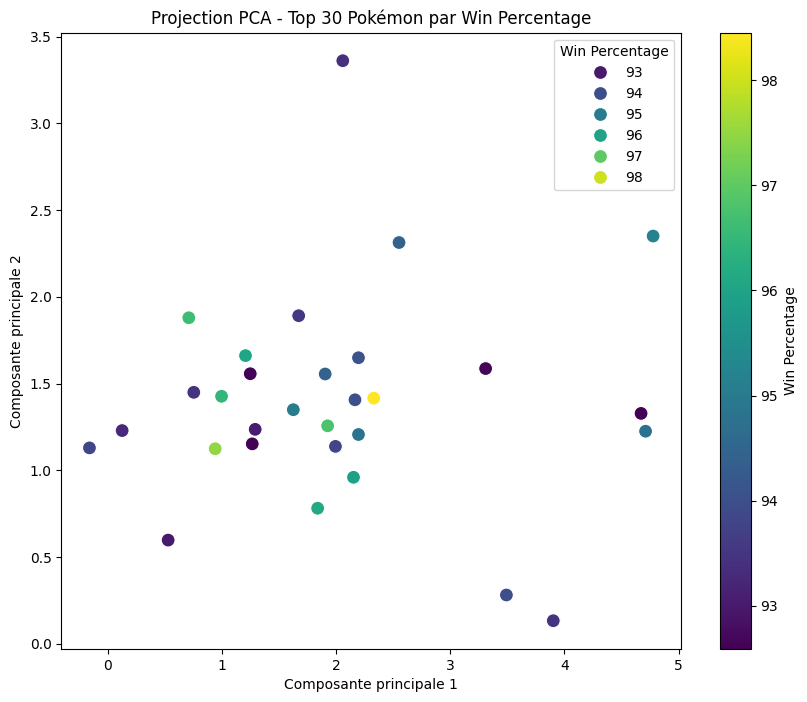

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Top 30 Pokémon par Win Percentage
top_pokemon = pokemon.nlargest(30, 'Win Percentage')

# PCA déjà calculé dans X_pca
X_pca_top = X_pca[top_pokemon.index]

plt.figure(figsize=(10, 8))
ax = sns.scatterplot(
    x=X_pca_top[:,0],
    y=X_pca_top[:,1],
    hue=top_pokemon['Win Percentage'],
    palette='viridis',
    legend='brief',
    s=100
)

plt.title("Projection PCA - Top 30 Pokémon par Win Percentage")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")

norm = plt.Normalize(top_pokemon['Win Percentage'].min(), top_pokemon['Win Percentage'].max())
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Win Percentage')

plt.show()


In [26]:
import plotly.express as px
import pandas as pd

# Préparer un DataFrame avec les deux composantes PCA et le nom + win percentage
pca_df = pd.DataFrame({
    'PC1': X_pca[:,0],
    'PC2': X_pca[:,1],
    'Name': pokemon['Name'],
    'Win Percentage': pokemon['Win Percentage']
})

# Création du scatter plot interactif
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Win Percentage',
    hover_name='Name',
    color_continuous_scale='Viridis',
    title='Projection PCA des Pokémon colorée par Win Percentage',
    labels={'PC1': 'Composante principale 1', 'PC2': 'Composante principale 2'}
)

fig.update_layout(coloraxis_colorbar=dict(title='Win Percentage'))
fig.show()


# Synthèse finale - Analyse et prédiction du Win Percentage des Pokémon

## 1. Préparation et nettoyage des données
- Les datasets Pokémon et combats ont été chargés et fusionnés.
- Les valeurs manquantes ont été corrigées, notamment pour le Pokémon #62 (Primeape).
- La colonne `Type 2` manquante a été remplacée par la valeur `"None"`.

## 2. Calcul du Win Percentage
- Le pourcentage de victoires a été calculé pour chaque Pokémon à partir des données de combats.
- Le top 10 des Pokémon avec le plus haut Win Percentage comprend majoritairement des formes méga-évoluées et des Pokémon légendaires.

## 3. Analyse exploratoire et visualisations
- Une matrice de corrélation a montré que la statistique **Speed** est fortement corrélée au Win Percentage (corrélation ~0.91).
- D’autres statistiques comme **Attack** et **Special Attack** présentent aussi des corrélations modérées.
- La réduction dimensionnelle via PCA a permis de visualiser les Pokémon dans un espace réduit, coloré par leur taux de victoire, confirmant la relation entre caractéristiques physiques et performance en combat.
- Un graphique interactif a facilité l’exploration des données en affichant le nom des Pokémon au survol.

## 4. Modélisation et prédiction
- Trois modèles de régression ont été entraînés : Régression Linéaire, Random Forest, et XGBoost.
- XGBoost a montré la meilleure performance initiale avec un MAE d’environ 4.79.
- Un tuning hyperparamétrique étendu a permis d’optimiser XGBoost, atteignant un MAE final d’environ 5.23.
- LightGBM a été testé mais sans tuning poussé, donnant des résultats moins bons.

## 5. Perspectives d’amélioration
- Un tuning plus approfondi, notamment sur LightGBM et d’autres algorithmes, pourrait encore améliorer les performances.
- Le feature engineering avancé (création d’interactions entre statistiques) est une piste importante pour améliorer la prédiction.
- L’utilisation de méthodes d’ensemble (stacking) pourrait combiner les forces de plusieurs modèles.
- Une validation croisée plus rigoureuse et l’analyse des erreurs permettraient de mieux généraliser les résultats.

---

## Conclusion

Cette étude démontre que les statistiques physiques des Pokémon, notamment leur vitesse et attaque, sont des indicateurs forts de leurs performances en combat. Grâce à une approche combinée d’analyse exploratoire, modélisation et optimisation, il est possible de prédire de manière fiable le taux de victoire des Pokémon, ce qui peut être un outil précieux pour la stratégie dans les combats.


In [33]:
import pandas as pd

# Exemple : Stats de Pikachu (approximatives)
pikachu = pd.DataFrame([{
    'HP': 35,
    'Attack': 55,
    'Defense': 40,
    'Sp. Atk': 50,
    'Sp. Def': 50,
    'Speed': 90,
    'Type 1': 'Electric',
    'Type 2': 'None',
    'Legendary': False
}])

# Prédiction avec le modèle XGBoost tuné (random_search déjà entraîné)
win_pred_pikachu = random_search.predict(pikachu)

print(f"Win Percentage prédit pour Pikachu : {win_pred_pikachu[0]:.2f}%")


Win Percentage prédit pour Pikachu : 63.19%


In [ ]:
!git add .
!git commit -m "Pokemon Data Analysis Tutorial - Préprocessing, Modélisation et Évaluation"
!git push origin main